<a href="https://colab.research.google.com/github/jamesiswanto/Velocity-and-Acceleration-Analysis-Using-Polynomial-and-Lagrangian-Interpolation-Methods/blob/development/Velocity_and_Acceleration_Analysis_Using_Polynomial_and_Lagrangian_Interpolation_Methods.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, diff, lambdify

In [23]:
def polynomial_order2(t_values, v_values):
    """
    Calculate the coefficients of a second-order polynomial using Gaussian Elimination.

    Parameters:
    t_values (list): Time values [t0, t1, t2]
    v_values (list): Velocity values [v(t0), v(t1), v(t2)]

    Returns:
    tuple: Coefficients (a0, a1, a2) of the polynomial v(t) = a0 + a1*t + a2*t^2
    """
    # Create the coefficient matrix
    A = np.array([
        [1, t_values[0], t_values[0]**2],
        [1, t_values[1], t_values[1]**2],
        [1, t_values[2], t_values[2]**2]
    ])

    # Create the right-hand side vector
    b = np.array(v_values)

    # Solve the system of equations using Gaussian Elimination
    coefficients = np.linalg.solve(A, b)

    return coefficients

In [24]:
def evaluate_polynomial(coefficients, t):
    """
    Evaluate the polynomial v(t) = a0 + a1*t + a2*t^2 at a given t.

    Parameters:
    coefficients (tuple): The coefficients (a0, a1, a2)
    t (float): The time value to evaluate at

    Returns:
    float: The value of v(t)
    """
    a0, a1, a2 = coefficients
    return a0 + a1*t + a2*t**2

In [25]:
def calculate_acceleration(coefficients, t):
    """
    Calculate the acceleration a(t) = d/dt(v(t)) at a given t.

    Parameters:
    coefficients (tuple): The coefficients (a0, a1, a2)
    t (float): The time value to evaluate at

    Returns:
    float: The acceleration a(t)
    """
    a0, a1, a2 = coefficients
    return a1 + 2*a2*t

In [26]:
def lagrange_interpolation_order1(t_values, v_values, t):
    """
    Perform Lagrangian interpolation of order 1.

    Parameters:
    t_values (list): Time values [t0, t1]
    v_values (list): Velocity values [v(t0), v(t1)]
    t (float): The time value to interpolate at

    Returns:
    float: The interpolated value v(t)
    """
    t0, t1 = t_values
    v0, v1 = v_values

    # Lagrangian basis functions
    L0 = (t - t1) / (t0 - t1)
    L1 = (t - t0) / (t1 - t0)

    # Interpolated value
    v_t = L0 * v0 + L1 * v1

    return v_t

In [27]:
def main():
    # Given data
    t_values_poly = [10, 15, 20]
    v_values_poly = [227.04, 362.78, 517.35]

    # Calculate coefficients for polynomial of order 2
    coefficients = polynomial_order2(t_values_poly, v_values_poly)
    a0, a1, a2 = coefficients

    print("Polynomial Interpolation (Order 2):")
    print(f"a0 = {a0:.2f}")
    print(f"a1 = {a1:.2f}")
    print(f"a2 = {a2:.2f}")
    print(f"v(t) = {a0:.2f} + {a1:.2f}t + {a2:.2f}t²")

    # Calculate acceleration at t = 16
    t_accel = 16
    acceleration = calculate_acceleration(coefficients, t_accel)
    print(f"a(t) = {a1:.2f} + {2*a2:.2f}t")
    print(f"a({t_accel}) = {acceleration:.2f}")

    # Lagrangian interpolation (Order 1)
    t_values_lagrange = [15, 20]
    v_values_lagrange = [362.78, 517.35]
    t_interp = 16

    v_lagrange = lagrange_interpolation_order1(t_values_lagrange, v_values_lagrange, t_interp)

    print("\nLagrangian Interpolation (Order 1):")
    print(f"v({t_interp}) = {v_lagrange:.3f}")

    # Visualize the interpolations
    t_range = np.linspace(5, 25, 100)
    v_poly = [evaluate_polynomial(coefficients, t) for t in t_range]

    # Plot
    plt.figure(figsize=(10, 6))

    # Plot polynomial interpolation
    plt.plot(t_range, v_poly, 'b-', label='Polynomial (Order 2)')
    plt.scatter(t_values_poly, v_values_poly, color='blue', s=50, label='Data Points (Poly)')

    # Calculate Lagrangian interpolation for visualization
    v_lagrange_range = [lagrange_interpolation_order1(t_values_lagrange, v_values_lagrange, t) for t in t_range]
    plt.plot(t_range, v_lagrange_range, 'r--', label='Lagrangian (Order 1)')
    plt.scatter(t_values_lagrange, v_values_lagrange, color='red', s=50, label='Data Points (Lagrange)')

    # Mark the interpolated point at t=16
    plt.scatter([t_interp], [v_lagrange], color='green', s=100, label=f'Interpolated at t={t_interp}')

    plt.title('Velocity vs Time Interpolation')
    plt.xlabel('Time (t)')
    plt.ylabel('Velocity v(t)')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig('interpolation_plot.png')
    plt.show()

    # Calculate symbolic derivative for acceleration
    t_sym = symbols('t')
    v_sym = a0 + a1*t_sym + a2*t_sym**2
    a_sym = diff(v_sym, t_sym)

    print("\nSymbolic expressions:")
    print(f"v(t) = {v_sym}")
    print(f"a(t) = {a_sym}")

Polynomial Interpolation (Order 2):
a0 = 12.05
a1 = 17.73
a2 = 0.38
v(t) = 12.05 + 17.73t + 0.38t²
a(t) = 17.73 + 0.75t
a(16) = 29.78

Lagrangian Interpolation (Order 1):
v(16) = 393.694


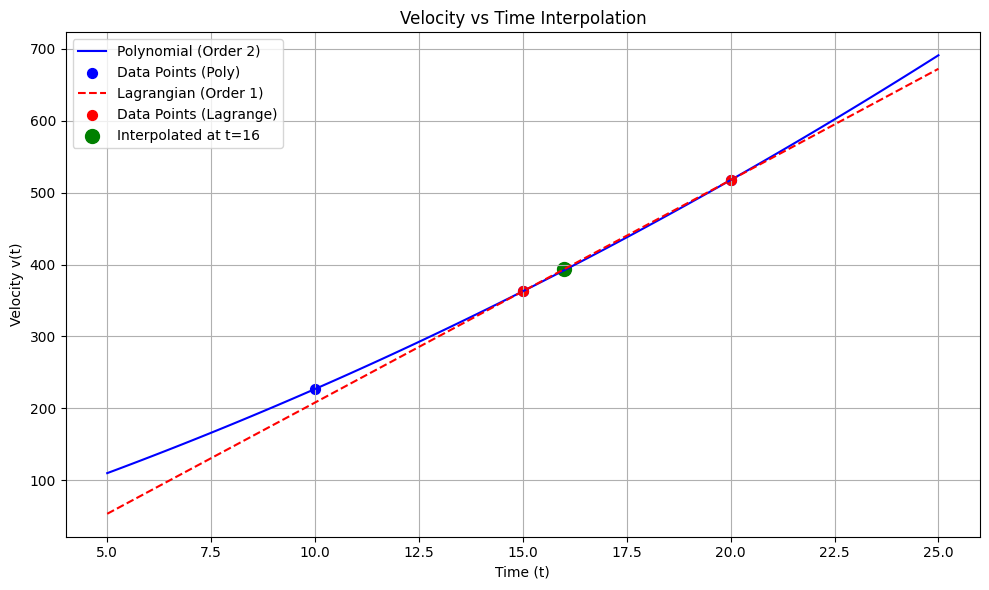


Symbolic expressions:
v(t) = 0.376600000000002*t**2 + 17.7329999999999*t + 12.0500000000003
a(t) = 0.753200000000004*t + 17.7329999999999


In [28]:
if __name__ == "__main__":
    main()